# 02 — Train Card Detector

Train YOLOv11 phát hiện thẻ CCCD (class `card`).

**Yêu cầu:** Chạy `01_prepare_yolo_data.ipynb` **trong cùng session** trước.

**Tiêu chí pass:** mAP@0.5 ≥ 0.85 → chuyển sang Field Detector.

> Sau khi train xong, weights sẽ được tải xuống máy qua `files.download()`.

## 0. Cài đặt

In [7]:
!pip install ultralytics -q

In [8]:
import json
import shutil
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import gdown
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
import yaml
from tqdm.notebook import tqdm
from ultralytics import YOLO

FILE_ID   = "1CzgcY8qbT0HkcBpJdHB5-5rNXvO9kSlZ"

BASE_DIR  = Path("/content")
DATA_YAML = BASE_DIR / "data/yolo/card/data.yaml"
RUNS_DIR  = BASE_DIR / "runs/card_detector"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
# 1. Download zip
zip_path = BASE_DIR / "cccd_data.zip"
gdown.download(id=FILE_ID, output=str(zip_path), quiet=False)

# 2. Giải nén
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(str(BASE_DIR))

# 3. Convert COCO → YOLO
RAW_DIR    = BASE_DIR / "data/cccd.v1i.coco"
SPLITS_DIR = BASE_DIR / "data/processed/splits"
YOLO_DIR   = BASE_DIR / "data/yolo"

# Build bảng tra cứu ảnh
fname_to_path = {}
for split in ["train", "valid", "test"]:
    for p in (RAW_DIR / split).glob("*.jpg"):
        fname_to_path[p.name] = p

def coco_bbox_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    cx = max(0.0, min(1.0, (x + w / 2) / img_w))
    cy = max(0.0, min(1.0, (y + h / 2) / img_h))
    w  = max(0.0, min(1.0, w / img_w))
    h  = max(0.0, min(1.0, h / img_h))
    return cx, cy, w, h

def convert_split(coco_path, split_name, target_classes, out_dir):
    img_out   = out_dir / "images" / split_name
    label_out = out_dir / "labels" / split_name
    img_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    with open(coco_path, encoding="utf-8") as f:
        coco = json.load(f)

    cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
    class_to_idx   = {cls: i for i, cls in enumerate(target_classes)}

    anns_by_img = defaultdict(list)
    for ann in coco["annotations"]:
        if cat_id_to_name.get(ann["category_id"]) in class_to_idx:
            anns_by_img[ann["image_id"]].append(ann)

    for img_info in tqdm(coco["images"], desc=f"  {split_name}", leave=False):
        src = fname_to_path.get(img_info["file_name"])
        if src is None:
            continue
        dst = img_out / img_info["file_name"]
        if not dst.exists():
            shutil.copy2(src, dst)
        lines = []
        for ann in anns_by_img.get(img_info["id"], []):
            cls = cat_id_to_name[ann["category_id"]]
            cx, cy, w, h = coco_bbox_to_yolo(ann["bbox"], img_info["width"], img_info["height"])
            lines.append(f"{class_to_idx[cls]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        (label_out / (Path(img_info["file_name"]).stem + ".txt")).write_text("\n".join(lines))

# Convert card
card_dir = YOLO_DIR / "card"
for sn, fn in [("train", "train.json"), ("val", "val.json"), ("test", "test.json")]:
    convert_split(SPLITS_DIR / fn, sn, ["card"], card_dir)

card_yaml = {"path": str(card_dir), "train": "images/train", "val": "images/val",
              "test": "images/test", "nc": 1, "names": ["card"]}
(card_dir / "data.yaml").write_text(yaml.dump(card_yaml))

# Convert field
field_classes = ["id", "name", "birth", "origin", "address", "title"]
field_dir = YOLO_DIR / "field"
for sn, fn in [("train", "train.json"), ("val", "val.json"), ("test", "test.json")]:
    convert_split(SPLITS_DIR / fn, sn, field_classes, field_dir)

field_yaml = {"path": str(field_dir), "train": "images/train", "val": "images/val",
              "test": "images/test", "nc": len(field_classes), "names": field_classes}
(field_dir / "data.yaml").write_text(yaml.dump(field_yaml))

Downloading...
From (original): https://drive.google.com/uc?id=1CzgcY8qbT0HkcBpJdHB5-5rNXvO9kSlZ
From (redirected): https://drive.google.com/uc?id=1CzgcY8qbT0HkcBpJdHB5-5rNXvO9kSlZ&confirm=t&uuid=bb399698-60dc-4c5e-add6-943b76774876
To: /content/cccd_data.zip
100%|██████████| 629M/629M [00:08<00:00, 73.9MB/s]


  train:   0%|          | 0/3074 [00:00<?, ?it/s]

  val:   0%|          | 0/699 [00:00<?, ?it/s]

  test:   0%|          | 0/626 [00:00<?, ?it/s]

  train:   0%|          | 0/3074 [00:00<?, ?it/s]

  val:   0%|          | 0/699 [00:00<?, ?it/s]

  test:   0%|          | 0/626 [00:00<?, ?it/s]

145

In [10]:
import json
from pathlib import Path

import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

DATA_YAML  = Path("/content/data/yolo/card/data.yaml")
RUNS_DIR   = Path("/content/runs/card_detector")

assert DATA_YAML.exists()
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_YAML: {DATA_YAML}")
print(f"RUNS_DIR:  {RUNS_DIR}")

DATA_YAML: /content/data/yolo/card/data.yaml
RUNS_DIR:  /content/runs/card_detector


## 1. Cấu hình training

In [11]:
MODEL_SIZE = "yolo11s.pt"  # n=nano, s=small, m=medium
EPOCHS     = 100
IMGSZ      = 640
BATCH      = 16
PATIENCE   = 20
SEED       = 42
MAP_TARGET = 0.85

## 2. Train

In [12]:
model = YOLO(MODEL_SIZE)

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=PATIENCE,
    seed=SEED,
    project=str(RUNS_DIR),
    name="exp",
    exist_ok=True,
    rect=False,
    degrees=20.0,
    translate=0.1,
    scale=0.5,
    perspective=0.001,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    verbose=True,
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/yolo/card/data.yaml, degrees=20.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspecti

## 3. Evaluate trên val set

In [13]:
best_weights = RUNS_DIR / "exp" / "weights" / "best.pt"
model_best   = YOLO(best_weights)

val_results = model_best.val(data=str(DATA_YAML), split="val", imgsz=IMGSZ, verbose=False)
map50 = float(val_results.box.map50)

print("=== Val Results ===")
print(f"  mAP@0.5:    {map50:.4f}")
print(f"  mAP@0.5:95: {val_results.box.map:.4f}")
print(f"  Precision:  {val_results.box.mp:.4f}")
print(f"  Recall:     {val_results.box.mr:.4f}")
print()
if map50 >= MAP_TARGET:
    print(f"  PASS: {map50:.4f} >= {MAP_TARGET} ")
else:
    print(f"  FAIL: {map50:.4f} < {MAP_TARGET} ")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1407.9±509.2 MB/s, size: 59.0 KB)
val: Scanning /content/data/yolo/card/labels/val.cache... 699 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 699/699 325.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 3.7it/s 11.8s
                   all        699        699          1          1      0.995      0.907
Speed: 1.6ms preprocess, 10.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val
=== Val Results ===
  mAP@0.5:    0.9950
  mAP@0.5:95: 0.9068
  Precision:  0.9998
  Recall:     1.0000

  PASS: 0.9950 >= 0.85 


## 4. Evaluate trên test set

In [14]:
test_results = model_best.val(data=str(DATA_YAML), split="test", imgsz=IMGSZ, verbose=False)

print(f"  mAP@0.5:    {test_results.box.map50:.4f}")
print(f"  mAP@0.5:95: {test_results.box.map:.4f}")
print(f"  Precision:  {test_results.box.mp:.4f}")
print(f"  Recall:     {test_results.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2331.2±572.9 MB/s, size: 97.1 KB)
val: Scanning /content/data/yolo/card/labels/test... 626 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 626/626 2.1Kit/s 0.3s
val: New cache created: /content/data/yolo/card/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 3.5it/s 11.5s
                   all        626        624       0.99      0.994      0.995      0.906
Speed: 1.8ms preprocess, 11.4ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val2
  mAP@0.5:    0.9948
  mAP@0.5:95: 0.9057
  Precision:  0.9903
  Recall:     0.9936


## 5. Visualize training curves

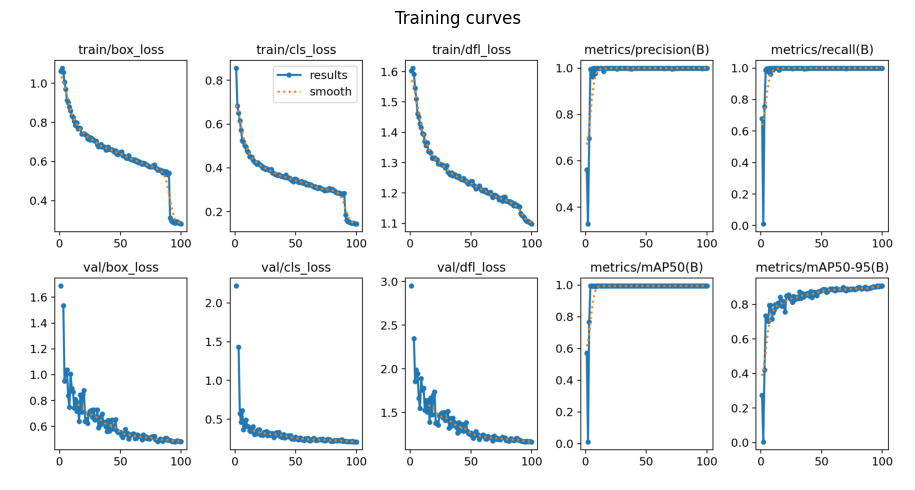

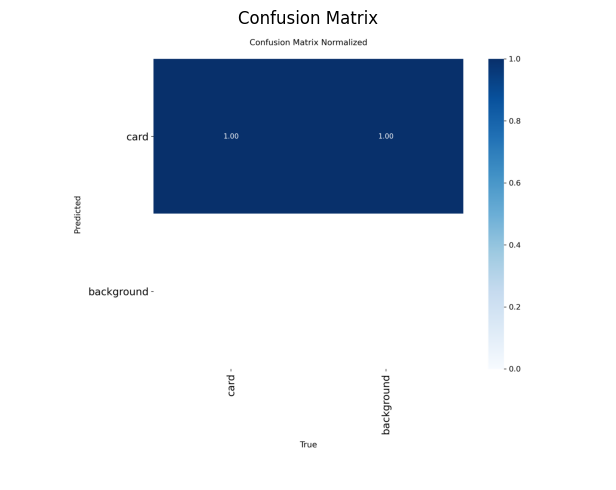

In [15]:
exp_dir = RUNS_DIR / "exp"

for png_name, title in [
    ("results.png", "Training curves"),
    ("confusion_matrix_normalized.png", "Confusion Matrix"),
    ("PR_curve.png", "PR Curve"),
]:
    png = exp_dir / png_name
    if png.exists():
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(mpimg.imread(png))
        ax.axis("off")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()

## 6. Test thử trên ảnh mẫu

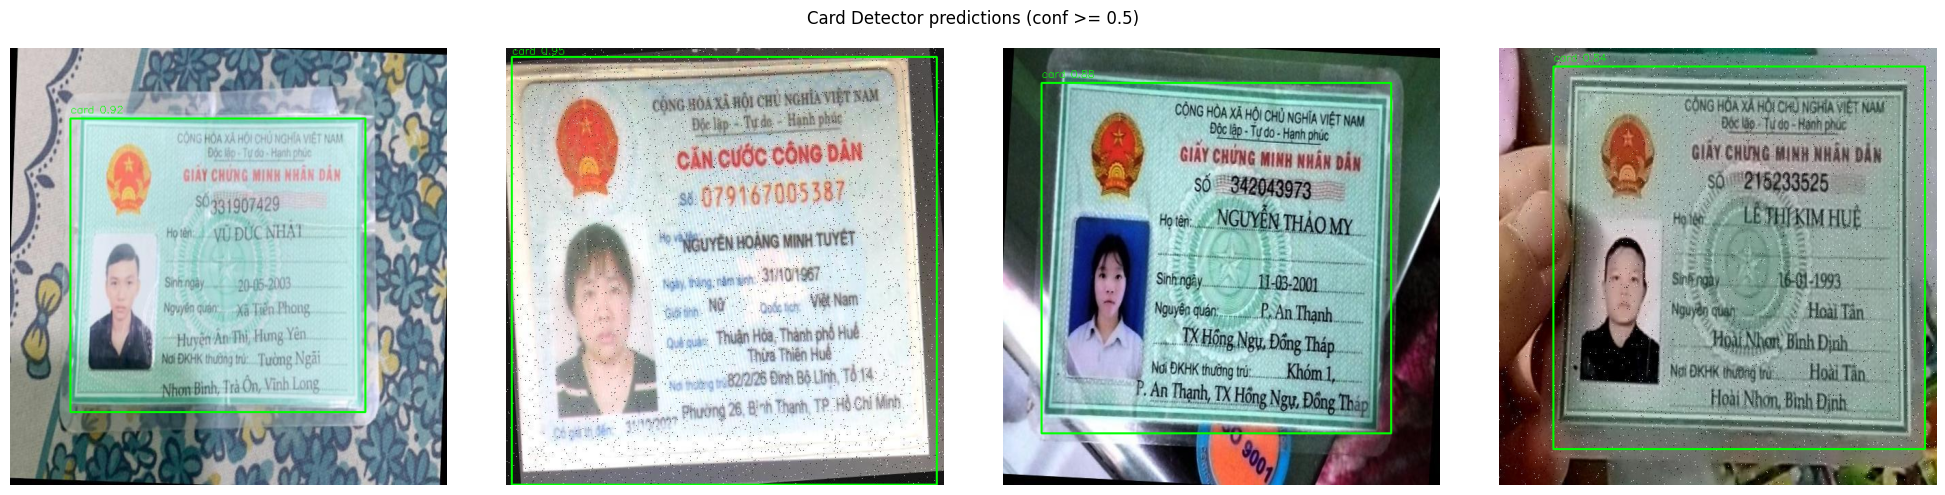

In [16]:
test_imgs = list(Path("/content/data/yolo/card/images/test").glob("*.jpg"))[:4]

fig, axes = plt.subplots(1, len(test_imgs), figsize=(5 * len(test_imgs), 5))
if len(test_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, test_imgs):
    preds = model_best.predict(img_path, imgsz=IMGSZ, conf=0.5, verbose=False)[0]
    img   = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"card {conf:.2f}", (x1, max(y1 - 8, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Card Detector predictions (conf >= 0.5)")
plt.tight_layout()
plt.show()

## 7. Lưu kết quả & Tải weights về máy

In [17]:
eval_result = {
    "model": MODEL_SIZE,
    "val": {
        "map50":     round(float(val_results.box.map50), 4),
        "map50_95":  round(float(val_results.box.map), 4),
        "precision": round(float(val_results.box.mp), 4),
        "recall":    round(float(val_results.box.mr), 4),
        "pass":      float(val_results.box.map50) >= MAP_TARGET,
    },
    "test": {
        "map50":     round(float(test_results.box.map50), 4),
        "map50_95":  round(float(test_results.box.map), 4),
        "precision": round(float(test_results.box.mp), 4),
        "recall":    round(float(test_results.box.mr), 4),
    },
    "config": {"epochs": EPOCHS, "imgsz": IMGSZ, "batch": BATCH, "seed": SEED},
}

eval_path = exp_dir / "eval_results.json"
with open(eval_path, "w") as f:
    json.dump(eval_result, f, indent=2)

print(json.dumps(eval_result, indent=2))

{
  "model": "yolo11s.pt",
  "val": {
    "map50": 0.995,
    "map50_95": 0.9068,
    "precision": 0.9998,
    "recall": 1.0,
    "pass": true
  },
  "test": {
    "map50": 0.9948,
    "map50_95": 0.9057,
    "precision": 0.9903,
    "recall": 0.9936
  },
  "config": {
    "epochs": 100,
    "imgsz": 640,
    "batch": 16,
    "seed": 42
  }
}


In [18]:
# # Tải weights + eval về máy
# from google.colab import files

# files.download(str(best_weights))   # best.pt
# files.download(str(eval_path))      # eval_results.json